# Chapter 17 - P and NP Problems

## Learning Objectives

After completing this chapter, you will be able to:

* Understand the mathematical concept of a graph consisting of a set of nodes and edges.
* Understand what is meant by a problem that is solvable in *polynomial time*, a.k.a. in *P*.
* Understand what it means for a problem to be solvable in *nondeterministic polynomial time*, a.k.a. in *NP*.

*Note* - It might be valuable to review the appendix on the growth of functions before reading this chapter.

We use these libraries to build and visualize the objects we'll be using in this chapter:

| Package | Purpose |
|---|---|
| `io` | Basic library for handling input and output |
| `base64` | Manages special characters |
| `IPython` | Provides additional Python functionality |
| `graphviz` | General graph visualization |
| `numpy` | Basic numerical (arrays) library |
| `matplotlib.pyplot` | Visualization library based on MATLAB |
| `networkx` | Library for studiying complex networks. |

The cell below checks whether each package is already installed and installs
it automatically if not. This is safe to re-run; it only installs what is
missing.

**Outside Jupyter**, install once from the terminal:
```bash
pip install io base64 IPython graphviz numpy matplotlib networkx
```

In [1]:
# Install required Python packages using pip
import sys
import importlib.util
import subprocess

def install_if_missing(package):
    if importlib.util.find_spec(package) is None:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"{package} has been installed")
    else:
        print(f"{package} is already installed")

required_packages = ['io', 'base64', 'IPython', 'graphviz', 'numpy', 'matplotlib', 'networkx']
for package in required_packages:
    install_if_missing(package)

import numpy as np
import matplotlib.pyplot as plt

import networkx as nx

from graphviz import Digraph, Source

import io
import base64
from IPython.display import display, HTML

io is already installed
base64 is already installed
IPython is already installed
graphviz is already installed
numpy is already installed
matplotlib is already installed
networkx is already installed


## Section 17.1 - Graphs

*Graph* is a word that might be overused in mathematics, in that it is used to describe multiple distinct ideas. But, unfortunately, natural language can be like that.

You've likely seen the term *graph* used primarily to describe a visualization of the relation between the input and the output of a function. For example, the graph of the function

$$f(x) = x^{2} - 3x + 2$$

looks like: 

NOTE: The code cells generating the plots in this chapter have mostly been hidden, but can be displayed in Jupyter if requested.


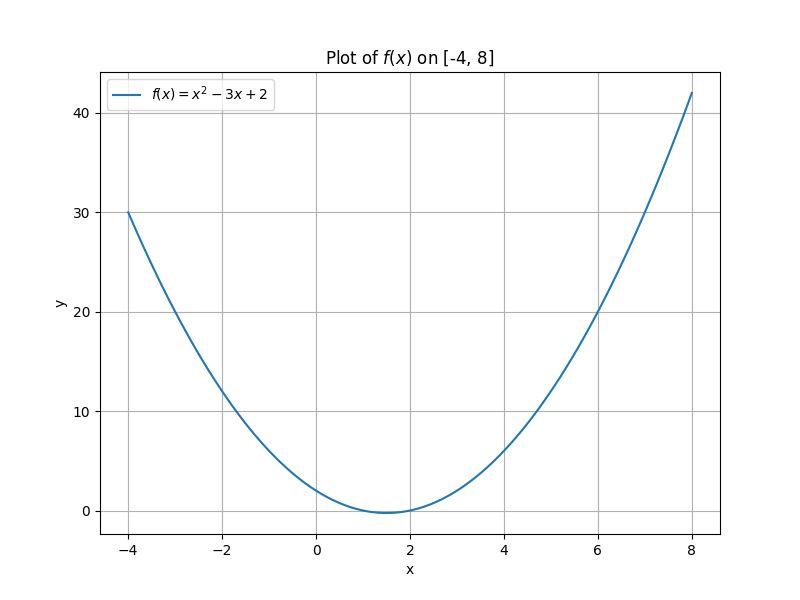

In [2]:
# Define the interval [-4, 8]
# generating 100 points between -4 and 8
x = np.linspace(-4, 8, 100)

# Define the function
f_x = x**2 - 3 * x + 2

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(x, f_x, label='$f(x) = x^2 - 3x + 2$')

# Add formatting (labels, title, legend, grid)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Plot of $f(x)$ on [-4, 8]')
plt.legend()
plt.grid(True)

# Create a figure number and title
figure_number = "1"
figure_title = "The Quadratic Function f(x) = x^2 - 3x + 2"

# Create the full caption string
figure_number_str = f"Figure {figure_number}"
full_caption = f"<b>{figure_number_str}:</b> {figure_title}"

# Create alternative text for screen readers
alt_text = (
    "A line graph of the quadratic function f(x) = x^2 - 3x + 2, plotted over the interval x=-4 to x=8. "
    "The graph is a parabola opening upwards. It reaches its minimum value of -0.25 at the vertex x=1.5. "
    "The function crosses the x-axis at x=1 and x=2. "
    "The plot starts at y=30 at x=-4 and ends at a maximum value of y=42 at x=8."
)

# Save the plot to a memory buffer instead of a file
buf = io.BytesIO()
plt.savefig(buf, format='png') # PNG is safest for accessibility tools
buf.seek(0)

# Encode the image data to Base64 (so it can go into HTML)
img_data = base64.b64encode(buf.read()).decode('utf-8')

# Create the HTML string with the ALT tag
mime_type = "image/png"

html_output = f"""
<figure style="text-align: center; margin: 1em 0;">
    <img src="data:{mime_type};base64,{img_data}" alt="{alt_text}"
         style="max-width: 100%; height: auto; display: block; margin: 0 auto;" />

    <figcaption style="margin-top: 0.5em; font-size: 0.9em; color: #333;">
        {full_caption}
    </figcaption>
</figure>
"""

# Close the plot (to prevent double display) and render the HTML
plt.close()
display(HTML(html_output))

However, the term *graph* is also used for a mathematical structure used to represents objects and their connections. This type of graph consists of objects called *vertices* or sometimes *nodes*, and connections between these vertices called *edges*.

Stated more formally:

---

**Definition** - A *graph* is a pair $(V,E)$ where $V$ is a set whose elements are called *vertices*, and $E$ is a set of unordered pairs $\{v_{i},v_{j}\}$ of vertices whose elements are called *edges*.

---

It's possible to also have graphs where the edges are ordered, so an edge "points" from one vertex to another. These are called *directed graphs*. It's also possible to have graphs where there can be more than one edge between two vertices, and these are called *multigraphs*. Sometimes the edges are assigned numbers, and these are called *weighted graphs*.

Let's create a Python *Graph* class corresponding with this definition. This class creates a graph based upon a list of vertices and tuples representing edges.

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# The (Undirected) Graph class.
#
# Running outside Jupyter:
#   python Graph.py
# ─────────────────────────────────────────────────────────────────────────────

class Graph:
    """
    Represents an Undirected Graph using an adjacency list structure.
    Includes an accessible show method using networkx and matplotlib.
    """
    def __init__(self, vertices=None, edges=None):
        """Initializes the graph."""
        self.graph = {}

        if vertices:
            for v in vertices:
                self.add_vertex(v)

        if edges:
            for u, v in edges:
                self.add_edge(u, v)

    def add_vertex(self, v):
        """Adds a vertex to the graph."""
        if v not in self.graph:
            self.graph[v] = []

    def add_edge(self, u, v):
        """Adds an undirected edge between u and v."""
        if u not in self.graph:
            self.add_vertex(u)
        if v not in self.graph:
            self.add_vertex(v)

        # Add the connection to both sides (since it is undirected)
        if v not in self.graph[u]:
             self.graph[u].append(v)
        if u not in self.graph[v]:
             self.graph[v].append(u)

    def degree(self, v):
        """Returns the degree of vertex v."""
        if v in self.graph:
            return len(self.graph[v])
        return 0

    def get_networkx_graph(self):
        """Helper to convert the internal representation to a networkx object."""
        G = nx.Graph()
        G.add_nodes_from(self.graph.keys())
        for u, neighbors in self.graph.items():
            for v in neighbors:
                # Only add the edge once for undirected graphs
                if u < v:
                    G.add_edge(u, v)
        return G

    def show(self, fig_num=None, title=None, alt_text="Undirected graph visualization.", format='png'):
        """
        Visualizes the graph using NetworkX and Matplotlib, and displays it
        accessibly with captioning and alt text.

        Parameters:
        - fig_num (str): Figure number (e.g., "Figure 5.1").
        - title (str): Title of the figure.
        - alt_text (str): Accessible description for screen readers.
        - format (str): Output format for the plot ('png' is standard).
        """
        # 1. Create the NetworkX graph object
        G = self.get_networkx_graph()

        # 2. Configure visualization (using spring layout for node positioning)
        pos = nx.spring_layout(G, k=0.8, iterations=50, seed=42)

        # Create figure
        plt.figure(figsize=(8, 6)) # Increased size slightly for better visibility

        # Draw the graph
        nx.draw(G, pos, with_labels=True, node_color='#ADD8E6', # Light Blue
                        node_size=2500, font_color='black',
                        font_weight='bold', font_size=12, edge_color='#666666')

        # Remove axes and border for clean visualization
        plt.box(False)
        plt.title(title or "Undirected Graph Visualization (NetworkX)", fontsize=14)

        # 3. Save the plot to a memory buffer
        buf = io.BytesIO()
        plt.savefig(buf, format=format)
        buf.seek(0)

        # 4. Close the plot to prevent double display
        plt.close()

        # 5. Accessibility and HTML Display (Same pattern as FA/GNFA)
        img_data = base64.b64encode(buf.read()).decode('utf-8')

        caption_content = ""
        if fig_num or title:
            caption_parts = []
            if fig_num:
                caption_parts.append(f"<b>Figure {fig_num}:</b>")
            if title:
                caption_parts.append(title)

            caption_content = " ".join(caption_parts)

        mime_type = f"image/{format}"

        html_output = f"""
        <figure style="text-align: center; margin: 1em 0;">
            <img src="data:{mime_type};base64,{img_data}" alt="{alt_text}"
                 style="max-width: 100%; height: auto; display: block; margin: 0 auto;" />

            {f'<figcaption style="margin-top: 0.5em; font-size: 0.9em; color: #333;">{caption_content}</figcaption>' if caption_content else ''}
        </figure>
        """
        display(HTML(html_output))

Let's create a simple triangular graph with three vertices and edges connecting each pair.

In [5]:
V_triangle = ['1', '2', '3']
E_triangle = [('1', '2'), ('1', '3'), ('2', '3')]

triangle_graph = Graph(vertices=V_triangle, edges=E_triangle)

Graphs are frequently displayed as a collection of dots (the vertices) and line segments between them (the edges). Our *Graph* class has a *show* method that displays the graph in this manner.


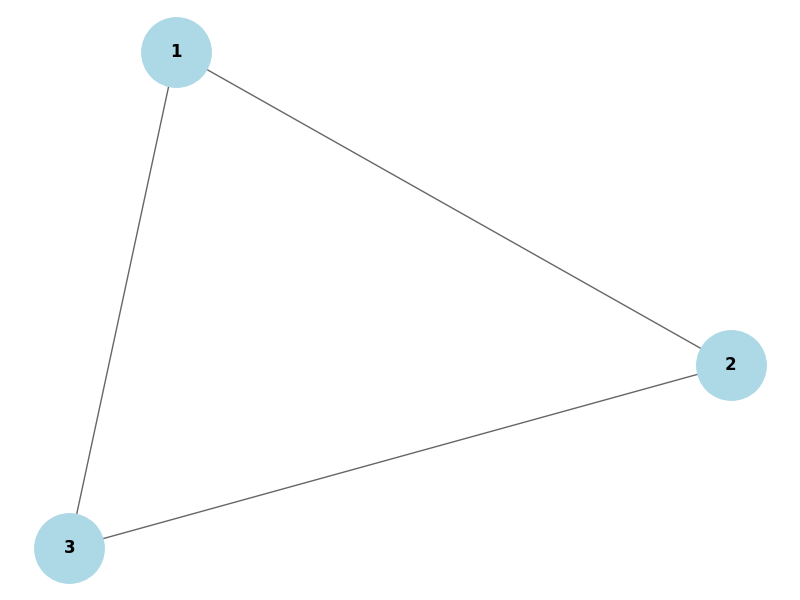

In [6]:
fig_num_2 = "2"
title_2 = "Graph Visualization of the Complete Graph K_3 (A Triangle)."
alt_text_2 = (
    "An undirected graph consisting of three vertices labeled 1, 2, and 3. "
    "Every vertex is connected to every other vertex, forming a closed triangle structure. "
    "The edges are (1, 2), (1, 3), and (2, 3)."
)

triangle_graph.show(fig_num_2, title_2, alt_text_2)

A fancy name for this graph is the complete graph on three ertices, which can be written as $K_{3}$.

---

**Example** - The graph with the set of vertices

$$V = \{u_{1}, u_{2}, u_{3}, v_{1}, v_{2}, v_{3}, v_{4}\}$$

and the set of edges

$$\displaystyle E = \{\{u_{1},v_{1}\}, \{u_{1},v_{2}\}, \{u_{1},v_{3}\}, \{u_{1},v_{4}\}, \{u_{2},v_{1}\}, \{u_{2},v_{2}\}, \{u_{2},v_{3}\}, \{u_{2},v_{4}\}, \{u_{3},v_{1}\}, \{u_{3},v_{2}\}, \{u_{3},v_{3}\}, \{u_{3},v_{4}\}\}$$

Can be created as an instance of our *Graph* class as:

In [7]:
V_34 = ['u1', 'u2', 'u3', 'v1', 'v2', 'v3', 'v4']

E_34 = [
    ('u1','v1'), ('u1','v2'), ('u1','v3'), ('u1','v4'),
    ('u2','v1'), ('u2','v2'), ('u2','v3'), ('u2','v4'),
    ('u3','v1'), ('u3','v2'), ('u3','v3'), ('u3','v4')
]

k34_graph = Graph(vertices=V_34, edges=E_34)

It's visualization looks like:


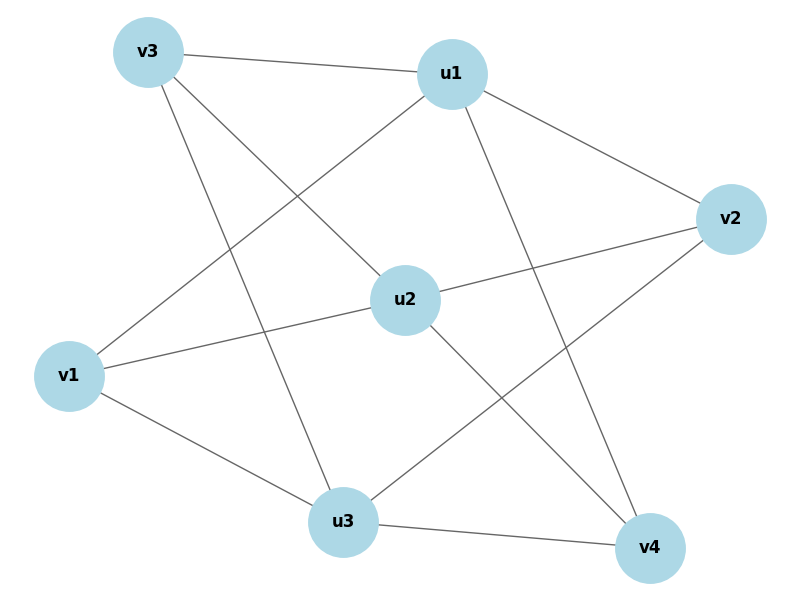

In [8]:
fig_num_3 = "3"
title_3 = "Graph Visualization of the Complete Bipartite Graph K_{3,4}."
alt_text_3 = (
    "A complete bipartite graph, K-3,4, consisting of seven vertices divided into two independent sets. "
    "The first set contains three vertices (u1, u2, u3), and the second set contains four vertices (v1, v2, v3, v4). "
    "The graph has twelve edges: every vertex in the first set is connected to every single vertex in the second set. "
    "There are no edges connecting vertices within the same set."
)

k34_graph.show(fig_num_3, title_3, alt_text_3)

All the nodes labeled $u_{i}$ on this graph are connected to the nodes labeled $v_{j}$, but none of the $u_{i}$ nodes are connected to each other, and neither are the $v_{j}$ nodes. This is an example of a type of graph called a *complete bipartite graph*, and this particular one is called the complete bipartite graph on $(3,4)$ vertices, and is denoted $K_{3,4}$.

---

The *degree* of a vertex is the number of edges connected to it. For example, in the graph $K_{3,4}$ above the degree of $u_{2}$ is $4$, while the degree of $v_{1}$ is $3$. Our *Graph* class has a *degree* method for returning the degree of each vertex.

In [9]:
print("The degree of u2 is: " + str(k34_graph.degree('u2')))
print("The degree of v1 is: " + str(k34_graph.degree('v1')))

The degree of u2 is: 4
The degree of v1 is: 3


---

**Definitions** - A *path* in a graph is a sequence of nodes where there is an edge between any node and the next one in the sequence. For example, the sequence:

$$\displaystyle v_{1} \rightarrow u_{2} \rightarrow v_{4} \rightarrow u_{3}$$

would be a path in $K_{3,4}$ above, but the sequence:

$$\displaystyle v_{1} \rightarrow u_{2} \rightarrow u_{3} \rightarrow v_{4}$$

would not be, as there is no edge connecting $u_{2}$ and $u_{3}$. A path that begins and ends on the same vertex is called a *circuit*. If there is more than one edge between a given pair of nodes, the path needs to specify which edge is taken.

We say two nodes are *connected* if there is a path in the graph that starts at one and ends at the other. A graph is *connected* if every pair of nodes within the graph are connected. Both of the graphs $K_{3}$ and $K_{3,4}$ above are connected. The graph below would not be, as there is, for example, no path from the node labeled $n0$ to the node labeled $n2$.

In [10]:
V_dis = ['n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7']
E_dis = [('n0', 'n1'), ('n2', 'n3'), ('n3', 'n4'), ('n3', 'n7'),
 ('n4', 'n5'), ('n4', 'n6'), ('n5', 'n6'), ('n6', 'n7')]

disconnected_graph = Graph(vertices=V_dis, edges=E_dis)


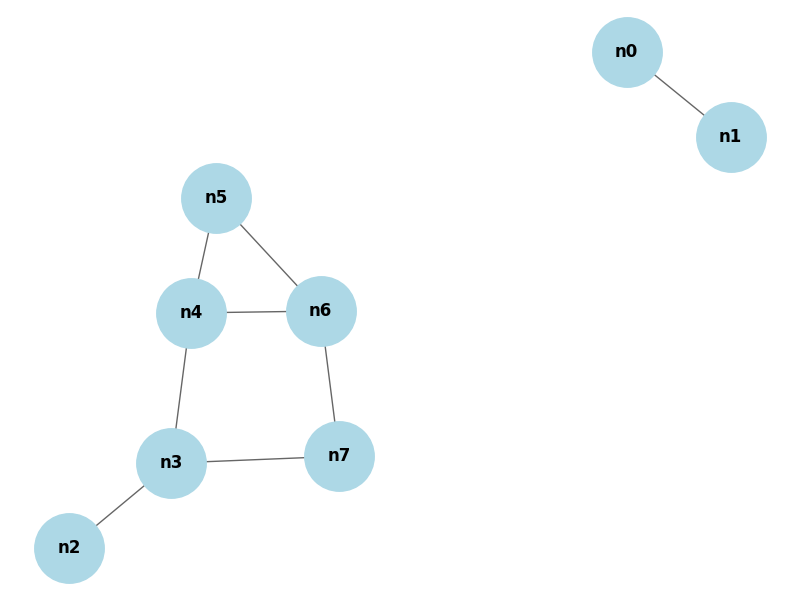

In [11]:
fig_num_4 = "4"
title_4 = "Disconnected Graph Consisting of Two Components."
alt_text_4 = (
    "A disconnected undirected graph with eight vertices labeled n0 through n7. "
    "The graph consists of two separate components: "
    "1. An isolated edge connecting vertex n0 and vertex n1. "
    "2. A larger component involving vertices n2, n3, n4, n5, n6, and n7. "
    "Within the larger component, the center node is n3, connected to n2, n4, and n7. "
    "Nodes n4, n5, n6, and n7 form a cycle, with n5, n6, and n7 also forming a clique."
)

disconnected_graph.show(fig_num_4, title_4, alt_text_4)

We can create a function that determines whether an instance of our *Graph* class is connected, and add it as a method to our class.

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Method that determines if a graph is connected.
#
# ─────────────────────────────────────────────────────────────────────────────

def is_connected(self):
    """
    Checks if the graph is connected using Breadth-First Search (BFS).
    This runs in Polynomial time O(V + E).
    """
    if not self.graph:
        return True

    start_node = next(iter(self.graph))
    visited = set()
    queue = [start_node]

    while queue:
        vertex = queue.pop(0)
        if vertex not in visited:
            visited.add(vertex)
            queue.extend([n for n in self.graph[vertex] if n not in visited])

    return len(visited) == len(self.graph)

In [13]:
# Add the method to our Graph class.
Graph.is_connected = is_connected

We can check this on some of our graphs:

In [14]:
k34_graph.is_connected()

True

In [15]:
disconnected_graph.is_connected()

False

---

## Section 17.2 - The K&ouml;nigsberg Bridge Problem

In the 18th century the city of K&ouml;nigsberg in Prussia (now Kaliningrad, Russia) was set on both sides of the Pregel River, and included two large islands—Kneiphof and Lomse—which were connected to each other, and to the two mainland portions of the city, by seven bridges.

<center>
<figure>
    <img src="https://github.com/yzhangweber/cs4110-jupyterbook/blob/main/content/Part_4_Advanced_Topics/Chapter_17/The_Konigsberg_Bridges.png?raw=true" height = "400" alt="The Bridges of Konigsberg">
    <figcaption><b>Figure 5.</b> <a href="https://en.wikipedia.org/wiki/File:Konigsberg_bridges.png" target="_blank">"Konigsberg bridges"</a> by <a>Bogdan Giuşcă</a> is licensed under <a href="http://creativecommons.org/licenses/by-sa/3.0" target="_blank">CC BY-SA 3.0</a>
</figure>
</center>

The K&ouml;nigsberg bridge problem was whether it was possible to devise a walk through the city that crossed each bridge only once. Many people played around with this problem and nobody was able to find a solution.

In 1736 the great mathematician Leonhard Euler published a mathematical proof that the problem was, in fact, impossible to solve. He did this by first formulating the problem as a question about a graph, where the nodes of the graph were the land masses of K&ouml;nigsberg, and the edges were the bridges.

<center>
<figure>
    <img src="https://github.com/yzhangweber/cs4110-jupyterbook/blob/main/content/Part_4_Advanced_Topics/Chapter_17/Konigsberg_as_Graph.png?raw=true" height = "250" alt="Konigsberg as Graph">
    <figcaption><b>Figure 6.</b> <a href="https://commons.wikimedia.org/wiki/File:7_bridges.svg" target="_blank">"7 bridges"</a> by <a href="https://commons.wikimedia.org/wiki/User_talk:Chris-martin" target="_blank">Chris-martin</a> is licensed under <a href="http://creativecommons.org/licenses/by-sa/3.0" target="_blank">CC BY-SA 3.0</a>
</figure>
</center>

The problem then became whether it was possible to find a path in the graph that traversed each edge exactly once. Euler proved that for any connected graph this is possible if and only if no more than two vertices have an odd degree. Such a traversal is now called an *Euler path*, and if the path begins and ends on the same vertex, it is called an *Euler circuit*.

---

**Theorem** - For any connected graph

* An Euler path exists if no more than two nodes have an odd degree.

* An Euler circuit exists if no nodes have an odd degree, a.k.a. every nodes has an even degree.

---

For the graph corresponding with the bridges of K&ouml;nigsberg, all four nodes have odd degree, and so no Euler circuit or Euler path exists.

## Section 17.3 - Polynomial Time (P) Complexity

To create an algorithm to check whether a connected graph has an Euler circuit, we could try to list off all paths within the graph that don't traverse an edge more than once, and then check whether any of them traverse each edge. This is possible, and would work, but it would be a very inefficient way to do it.

On the other hand, using the theorem above we could create a much more efficient algorithm for answering the question. If we had a connected graph represented by a set of vertices $V$ and a set of edges $E$ we could determine whether the graph contained an Euler circuit with an algorithm that:

* Read in the vertices and created a list of these vertices where each element of the list had a corresponding count, with counts all initialized to $0$.
* Read in the edges and for each edge increment the count of both its vertices by $1$.
* Checked whether all the vertices in the list had an even count.

For example, for the graph $K_{3}$ above the algorithm would be given the vertices and edges as input:

$$V = \{v_{1},v_{2},v_{3}\}$$

$$E = \{\{v_{1},v_{2}\}, \{v_{1},v_{3}\}, \{v_{2},v_{3}\}\}$$

It would then read in the list of vertices and create a list of these vertices with corresponding counts, all initialized to $0$:

* $v_{1}: 0$
* $v_{2}: 0$
* $v_{3}: 0$

It would then read the first edge in $E$, $\{v_{1},v_{2}\}$, and increment the counts for both $v_{1}$ and $v_{2}$ by $1$:

* $v_{1}: 1$
* $v_{2}: 1$
* $v_{3}: 0$

It would then continue this process for every edge in $E$ and at the end the list would be:

* $v_{1}: 2$
* $v_{2}: 2$
* $v_{3}: 2$

As the counts are all even, the algorithm would return that, *yes*, an Euler circuit exists. Note that it wouldn't explicitly find a circuit, but one example for this graph would be $v_{1} \rightarrow v_{2} \rightarrow v_{3} \rightarrow v_{1}$.



We can create a function that checks whether a Graph instance has an Euler circuit, and add it as a method to our *Graph* class.

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Method that determines if a graph has an Euler circuit.
#
# ─────────────────────────────────────────────────────────────────────────────

def has_euler_circuit(self):
    """
    Determines if an Euler Circuit exists based on Euler's Theorem.
    1. The graph must be connected.
    2. Every vertex must have an even degree.
    """
    # Check Condition 1
    if not self.is_connected():
        return False

    # Check Condition 2
    for v in self.graph:
        if self.degree(v) % 2 != 0:
            return False

    return True

In [17]:
# Add the method to our Graph class.
Graph.has_euler_circuit = has_euler_circuit

We can check this on some of the graphs we created.

In [18]:
triangle_graph.has_euler_circuit()

True

In [19]:
k34_graph.has_euler_circuit()

False

How much time does this algorithm take to run? Well, it needs to create an element in the list for every vertex in the graph, then read in every edge and increment the count for two vertices, then check whether each count is even. The amount of time required for the first part would be a constant multiple of the number of vertices, for the second part a constant multiple of the number of edges, and for the third part a constant multiple of the number of vertices. We could express this as:

$$k_{1}|V| + k_{2}|E| + k_{3}|V| = (k_{1}+k_{2})|V| + k_{2}|E|$$

So, the amount of time required for this algorithm is linear (a degree one polynomial) in the number of vertices and the number of edges. We could say the complexity of the algorithm is *polynomial* (or, even stronger, *linear*) in the size (the number of vertices and number of edges) of the graph. This is an example of a polynomial time algorithm, and so we would say the complexity of the problem of determining whether a connected graph has an Euler circuit is in polynomial time, which we abbreviate as $P$.

## Section 17.4 - Nondeterministic Polynomial Time (NP) Complexity

An Euler path is one that traverses every edge of the graph exactly once. A natural analog of this would be a path that visits every vertex of the graph exactly once. A path like this is called a Hamilton path, after the great 19th century British mathematician William Rowan Hamilton.

More precisely, a *Hamilton path* in a graph is a path that contains each vertex of the graph exactly once. A *Hamilton circuit* is a circuit that contains each vertex of the graph exactly once except the first one in the path, which is also the last one.

For example, the graph $K_{3}$ has a Hamilton circuit (which also happens to be an Euler circuit):

$$v_{1} \rightarrow v_{2} \rightarrow v_{3} \rightarrow v_{1}$$

On the other hand, the graph $K_{3,4}$ has a Hamilton path, for example:

$$v_{1} \rightarrow u_{1} \rightarrow v_{2} \rightarrow u_{2} \rightarrow v_{3} \rightarrow u_{3} \rightarrow v_{4}$$

However, it does *not* contain a Hamilton circuit.

You might hope a simple algorithm like the one above for Euler circuits exists for determining whether a connected graph contains a Hamilton circuit. Perhaps surprisingly, no such algorithm is known, and it's *very* strong suspected (but not proven!) that no such algorithm exists. More precisely, there is no known algorithm that can check whether a connected graph contains a Hamilton circuit in an amount of time that is polynomial in the size (the number of vertices and edges) of the graph. The best general algorithms all must, essentially, just go through all the possible circuits that don't repeat a vertex (except at the beginning and end) and check each one to see if it's a Hamilton circuit. This isn't very efficient, and the amount of time this takes is exponential in the size of the graph.

Now, suppose instead of determining whether a graph contains a Hamilton circuit, you instead just want to check whether a given sequence of vertices is, indeed, a Hamilton circuit. In other words, you want to *verify* whether a proposed solution is correct. For example, suppose you have the graph $K_{5}$ (the complete graph on 5 vertices) below:

In [20]:
V_K5 = ['v1', 'v2', 'v3', 'v4', 'v5']

E_K5 = [
    ('v1', 'v2'), ('v1', 'v3'), ('v1', 'v4'), ('v1', 'v5'),
    ('v2', 'v3'), ('v2', 'v4'), ('v2', 'v5'),
    ('v3', 'v4'), ('v3', 'v5'),
    ('v4', 'v5')
]

k5_graph = Graph(vertices=V_K5, edges=E_K5)


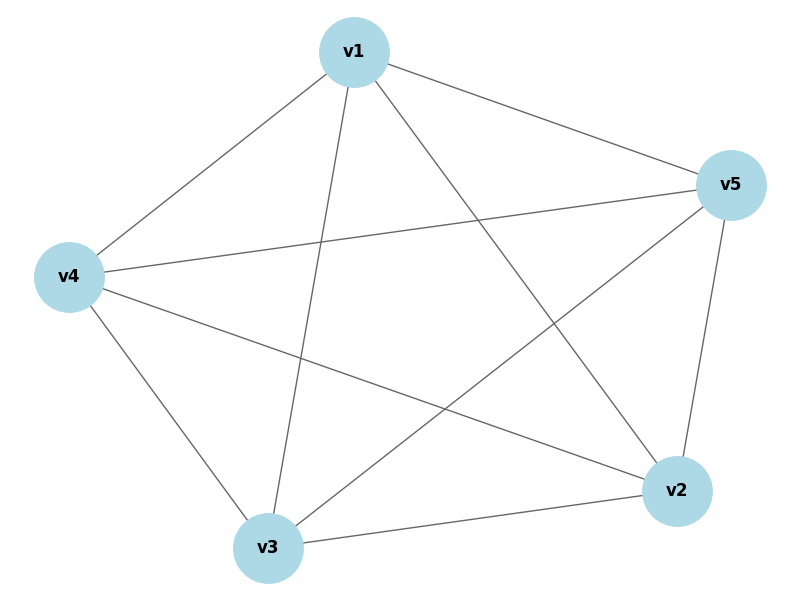

In [21]:
fig_num_7 = "7"
title_7 = "Graph Visualization of the Complete Graph K_5."
alt_text_7 = (
    "An undirected graph consisting of five vertices labeled v1, v2, v3, v4, and v5. "
    "The graph is a complete graph, K-5, meaning there are ten edges in total, with every unique pair of vertices connected by exactly one edge."
)

k5_graph.show(fig_num_7, title_7, alt_text_7)

and you're given the path:

$$\displaystyle v_{1} \rightarrow v_{4} \rightarrow v_{2} \rightarrow v_{5} \rightarrow v_{3} \rightarrow v_{1}$$

How would you check whether this was a Hamilton path? Well, an algorithm for doing so might be to go through the sequence of vertices in the path, and confirm that every vertex in the graph is in the sequence, no vertex in the sequnce repeats (except at the start and end), and every arrow in the sequence corresponds with an edge in the graph.

We can create a function for doing this, and add it as a method to our *Graph* class.

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# Method that verifies if a given path within a graph is a Hamilton circuit.
#
# ─────────────────────────────────────────────────────────────────────────────

def verify_hamilton_circuit(self, path):
    """
    Verifies if a given list of vertices is a valid Hamilton Circuit.
    This verification happens in Polynomial Time.
    """
    # 1. Check if path starts and ends at the same node
    if path[0] != path[-1]:
        return False

    # 2. Check length: Must visit every node once + return to start
    # Length should be |V| + 1
    if len(path) != len(self.graph) + 1:
        return False

    # 3. Check if the set of vertices in path matches vertices in graph
    if set(path) != set(self.graph.keys()):
        return False

    # 4. Walk the path and ensure every step follows a real edge
    for i in range(len(path) - 1):
        u, v = path[i], path[i+1]

        # Check if v is a neighbor of u
        if v not in self.graph[u]:
            return False

    return True

In [23]:
# Add the method to our Graph class.
Graph.verify_hamilton_circuit = verify_hamilton_circuit

We can use this to verify the path we just discussed on the graph $K_{5}$ is a Hamilton circuit:

In [24]:
k5_graph.verify_hamilton_circuit(['v1', 'v4', 'v2', 'v5', 'v3', 'v1'])

True

How long does this algorithm take to run? It would be a constant multiple of the length of the path, which would be one more than the number of vertices in the graph. In other words, the amount of time required to check whether a solution is correct would be a polynomial (linear) function of the size of the graph. So, even though we might not be able to always determine if a solution exists in a polynomial amount of time, we are able to *verify* whether a proposed solution is valid in a polynomial amount of time. Problems for which this is the case are in *nondeterministic polynomial time* (NP) complexity. Stated more formally, a problem is in NP if you can determine in a polynomial amount of time whether a solution exists if you are provided with a correct solution.

Why do we call problems where a solution can be verified in a polynomial amount of time "nondeterministic" polynomial time? Well, the basic idea is that suppose we're using the "brute force" method of just listing out all the possible solutions and checking them one by one. As we list out possible solutions, we need to make choices. For example, suppose in the graph $K_{5}$ above we're trying to generate possible solutions, and we start on vertex $v_{1}$. Where do we go from there? We could go to $v_{2}$ or $v_{3}$ or $v_{4}$ or $v_{5}$. We need to *determine* the next step, and if we want to explore all the possibilities, we would need to do so *sequentially*. On the other hand, suppose we didn't need to determine the next step, and could explore all the possibilities *simultaneously*. In this nondeterministic case we'd be able to list out all the possible paths much more quickly, and checking them all simultaneously would only require a polynomial amount of time. In other words, if we could explore the set of possibilites nondeterministically (simultaneously) then we could determine whether a solution exists in a polynomial amount of time. If this is a bit confusing to you, don't worry about it, just remember than NP means a proposed solution can be verified in a polynomial amount of time.

## Section 17.5 - References and Further Reading

* "Introduction to the Theory of Computation" (Third Edition) by Michael Sipser: *Sections 7.1-7.3 - Measuring Complexity, The Class P, The Class NP*
* "Automata Theory, Languages, and Computation" (Third Edition) by John. E Hopcraft, Rajeev Matwani, and Jeffrey D. Ullman: *Section 10.1 - The Classes $P$ and $NP$*

## Section 17.6 - Practice Problems

### Problem 17.6.1 - The Snowplow Problem (Euler Circuits)

A snowplow driver is assigned to clear the snow in a specific neighborhood. The neighborhood consists of intersections (vertices) and streets (edges). The driver wants to plow every single street exactly once and return to the garage (start node) to save fuel. The neighborhood map is represented by a graph where every intersection connects to exactly 3 streets (a "3-regular" graph). Is it possible for the driver to achieve this goal? Why or why not?

### Problem 17.6.2 - The "Envelope" Puzzle

Consider a drawing of an envelope (a rectangle with an "X" drawn inside it connecting the corners, and a triangle "roof" on top). Can you draw this shape on paper without lifting your pencil and without tracing over any line twice? Hint: Model the corners/intersections as vertices and the lines as edges. Count the degree of the vertices.

### Problem 17.6.3 - Logistics and Verification

A logistics company needs to find a route for a delivery truck that visits 50 specific cities exactly once and returns to the distribution center.

* Is the problem of finding this specific route known to be solvable in Polynomial (P) time?

* If an intern hands the boss a proposed route written on a napkin, is the process of checking if that route is valid solvable in Polynomial (P) time?

### Problem 17.6.4 - The Handshake Problem

At a large dinner party, some guests shake hands with others. No one shakes hands with themselves, and you can't shake hands with the same person twice. Prove that the number of people who have shaken hands with an **odd** number of other people must be **even**. *Hint*: Think about the sum of degrees in a graph.

### Problem 17.6.5 - Network Reliability

You are designing a fiber-optic network for a campus. You have the map of buildings (nodes) and the cables connecting them (edges). You need to write a script to ensure that if any single cable breaks, the network remains connected (data can still flow from any building to any other building). Does the algorithm to check this property belong to class P?

## Section 17.7 - Programming Problems

### Problem 17.7.1 - The Museum Patrol

Scenario: You are designing a security protocol for a small art museum. The museum has 5 rooms (A, B, C, D, E) connected by hallways.

* Room A connects to B and C.

* Room B connects to A, C, D, and E.

* Room C connects to A, B, D, and E.

* Room D connects to B and C.

* Room E connects to B and C.

Task:

1. Create an instance of the Graph class representing this museum.

2. Use the has_euler_circuit() method to determine if a security guard can walk every hallway exactly once and return to the starting room.

In [ ]:
#YOUR CODE HERE

### Problem 17.7.2 - The Delivery Route

A delivery driver needs to visit 6 cities: Seattle, Portland, Boise, Ogden, Salt Lake, and Denver. The roads connect them as follows:

* Seattle $\leftrightarrow$ Portland, Boise

* Portland $\leftrightarrow$ Seattle, Boise, Salt Lake

* Boise $\leftrightarrow$ Seattle, Portland, Ogden

* Ogden $\leftrightarrow$ Boise, Salt Lake

* Salt Lake $\leftrightarrow$ Portland, Ogden, Denver

* Denver $\leftrightarrow$ Salt Lake

Task:

1. Create the graph with these vertices and edges.

2. The driver proposes the following route to hit every city exactly once: ['Seattle', 'Portland', 'Salt Lake', 'Denver', 'Ogden', 'Boise', 'Seattle'].

3. Use verify_hamilton_circuit to check if this route is valid.

4. If it returns False, analyze specific edges in the proposed path to explain exactly where the driver gets stuck.

In [ ]:
#YOUR CODE HERE

### Problem 17.7.3 - The Fully Connected Office

You are analyzing a local area network (LAN) for an office. The network consists of 5 computers. Every computer is connected directly to every other computer (a Mesh topology, or $K_5$).

Task:

1. Programmatically generate the edges for a $K_5$ graph (using itertools or manual lists).

2. Create the Graph object.

3. Prove that this topology is robust by checking if it contains an Euler Circuit.

4. Verify that the simple path ['1', '2', '3', '4', '5', '1'] is a valid Hamilton Circuit.

In [ ]:
#YOUR CODE HERE

### Problem 17.7.4 - Euler Path (Challenge)

We wrote a function for determining if a Graph instance has an Euler Circuit (all even degrees). Write a method has_euler_path(self) that returns True if the graph has an Euler Path (but not a circuit). Recall: An Euler Path exists if a graph is connected and exactly two vertices have an odd degree.

Add this method to the Graph class, and then run it on the following graph instance.

In [25]:
kite_vertices = ['A', 'B', 'C', 'D']
kite_edges = [
    ('A', 'B'),
    ('B', 'C'),
    ('C', 'A'),
    ('C', 'D')
]

kite_graph = Graph(vertices=kite_vertices, edges=kite_edges)


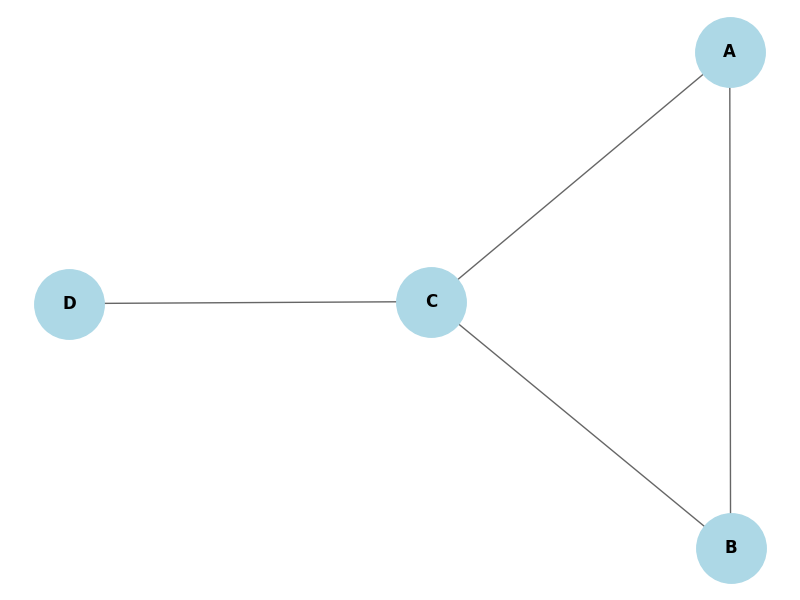

In [26]:
fig_num_8 = "8"
title_8 = "Graph Visualization of a Three-Cycle with One Pendant Vertex (Kite Graph)."
alt_text_8 = (
    "An undirected graph consisting of four vertices labeled A, B, C, and D, and four edges. "
    "The vertices A, B, and C form a closed cycle (a triangle), connected by edges (A, B), (B, C), and (C, A). "
    "Vertex D is connected only to vertex C, acting as a tail (or pendant vertex) to the main triangular cycle."
)

kite_graph.show(fig_num_8, title_8, alt_text_8)

In [ ]:
# YOUR CODE HERE